## Tier 3 B - XLS-R-300M fine-tune + AAM-Softmax

8-way Slavic LID, B-track Tier 3. Most expensive tier of the project.
Goal: confirm whether AAM-Softmax keeps winning over CE at the top of the model-capacity ladder.

**What's new vs Tier 1/2:**
- Input is raw 16 kHz waveform `(B, 48000)`, NOT log-Mel. XLS-R has its own learned conv frontend - feeding mels would discard the entire pretrained feature extractor.
- Model: `facebook/wav2vec2-xls-r-300m` (~300M params) -> mean-pool over time -> AAM-Softmax(m=0.2, s=10).
- Training: conv feature extractor FROZEN, transformer + head trained. Layer-wise LR (encoder 1e-5, head 1e-3). AdamW + linear warmup + cosine decay.
- Memory: batch=8 + grad-accum=4 = effective 32 under AMP. ~12 GB on T4.

**Run order:**
1. Cells 1-2 - preamble + verify the raw-wav Kaggle Dataset is attached.
2. Cell 3 - WavDataset (mmap) + AAM-Softmax head.
3. Cell 4 - XLS-R wrapper (frozen feat extractor + mean-pool).
4. Cell 5 - debug run (1k x 1 ep, ~3 min). Sanity gate.
5. Cell 6 - full training (5-8 ep, ~2-3 h on T4).
6. Cell 7 - final eval + artifacts.
7. Cell 8 - t-SNE of penultimate embeddings.

**Prereq:** run `tier3_b_precompute.ipynb` first to dump raw fp16 .npy files
to a Kaggle Dataset, then attach that dataset here at `/kaggle/input/slavic-lid-raw`.


In [1]:
## 1. Preamble - Kaggle, seeds, output dirs
from kaggle_secrets import UserSecretsClient
import os
try:
    os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")
except Exception:
    pass

import random, numpy as np, torch
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
if DEVICE == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))
    print("vram total:", torch.cuda.get_device_properties(0).total_memory / 1e9, "GB")

os.system("df -h /")

RUN_NAME    = "tier3_b"
RAW_DIR     = "/kaggle/input/datasets/antoniogatovski/slavic-lid-raw/raw"     # raw fp16 (N, 48000) waveforms - attach Kaggle Dataset here
WORK_ROOT   = "/kaggle/working/slavic_lid"
CKPT_DIR    = f"{WORK_ROOT}/ckpts/{RUN_NAME}"
LOG_DIR     = f"{WORK_ROOT}/logs/{RUN_NAME}"
RES_DIR     = f"{WORK_ROOT}/results/{RUN_NAME}"
for d in (CKPT_DIR, LOG_DIR, RES_DIR):
    os.makedirs(d, exist_ok=True)

LANGS = ['be', 'bg', 'cs', 'mk', 'pl', 'ru', 'sr', 'uk']
NUM_CLASSES = len(LANGS)
print("output dirs ready under", WORK_ROOT)


device: cuda
gpu: Tesla T4
vram total: 15.636037632 GB
Filesystem      Size  Used Avail Use% Mounted on
overlay         7.9T  6.8T  1.1T  87% /
output dirs ready under /kaggle/working/slavic_lid


In [2]:
 !ls -R /kaggle/input/

/kaggle/input/:
datasets

/kaggle/input/datasets:
antoniogatovski

/kaggle/input/datasets/antoniogatovski:
slavic-lid-raw

/kaggle/input/datasets/antoniogatovski/slavic-lid-raw:
__huggingface_repos__.json  raw

/kaggle/input/datasets/antoniogatovski/slavic-lid-raw/raw:
fleurs_labels.npy  test_labels.npy  train_labels.npy
fleurs_wavs.npy    test_wavs.npy    train_wavs.npy


In [3]:
## 2. Pre-flight - verify raw-wav Kaggle Dataset is attached
for split in ("train", "test", "fleurs"):
    for kind in ("wavs", "labels"):
        p = f"{RAW_DIR}/{split}_{kind}.npy"
        assert os.path.exists(p), (
            f"MISSING: {p}\n"
            f"-> Run tier3_b_precompute.ipynb first, save its /kaggle/working/raw/* "
            f"as a Kaggle Dataset, then attach it here at {RAW_DIR}.")
        print(f"OK  {p}  ({os.path.getsize(p)/1e9:.2f} GB)")


OK  /kaggle/input/datasets/antoniogatovski/slavic-lid-raw/raw/train_wavs.npy  (7.68 GB)
OK  /kaggle/input/datasets/antoniogatovski/slavic-lid-raw/raw/train_labels.npy  (0.00 GB)
OK  /kaggle/input/datasets/antoniogatovski/slavic-lid-raw/raw/test_wavs.npy  (10.31 GB)
OK  /kaggle/input/datasets/antoniogatovski/slavic-lid-raw/raw/test_labels.npy  (0.00 GB)
OK  /kaggle/input/datasets/antoniogatovski/slavic-lid-raw/raw/fleurs_wavs.npy  (0.59 GB)
OK  /kaggle/input/datasets/antoniogatovski/slavic-lid-raw/raw/fleurs_labels.npy  (0.00 GB)


In [4]:
## 3. WavDataset (mmap) + AAM-Softmax head

# - mmap_mode='r' keeps RAM flat - OS pages 48 kB chunks per __getitem__.
# - SpecAugment-equivalent for raw waveforms: skipped. XLS-R already trains with masking
#   internally; an extra time-mask on the input often hurts at this scale.
# - s=10 (matches Tier 2 final config). Embedding-collapse risk is much lower at 1024-d
#   than at 384-d, but staying consistent makes cross-tier comparison cleaner.
import math
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

class WavDataset(Dataset):
    def __init__(self, prefix):
        self.wavs   = np.load(f"{RAW_DIR}/{prefix}_wavs.npy",   mmap_mode="r")
        self.labels = np.load(f"{RAW_DIR}/{prefix}_labels.npy", mmap_mode="r")
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        w = torch.from_numpy(np.asarray(self.wavs[i], dtype=np.float32))  # (48000,)
        y = int(self.labels[i])
        return w, y


class AAMSoftmax(nn.Module):
    # Additive Angular Margin (ArcFace) head. Same as Tier 2.
    def __init__(self, in_features, n_classes, m=0.2, s=10.0):
        super().__init__()
        self.m, self.s = m, s
        self.W = nn.Parameter(torch.empty(n_classes, in_features))
        nn.init.xavier_normal_(self.W)
        self.cos_m = math.cos(m); self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m); self.mm = math.sin(math.pi - m) * m

    def forward(self, x, y=None):
        x_n = F.normalize(x,      dim=1)
        W_n = F.normalize(self.W, dim=1)
        cos = F.linear(x_n, W_n).clamp(-1.0 + 1e-7, 1.0 - 1e-7)
        if y is None:
            return self.s * cos
        sin   = torch.sqrt(1.0 - cos * cos)
        cos_t = cos * self.cos_m - sin * self.sin_m
        cos_t = torch.where(cos > self.th, cos_t, cos - self.mm)
        onehot = torch.zeros_like(cos).scatter_(1, y.view(-1, 1), 1.0)
        logits = onehot * cos_t + (1.0 - onehot) * cos
        return self.s * logits

# Smoke test
_d = WavDataset("train")
print("train samples:", len(_d), "first wav shape:", _d[0][0].shape, "label:", _d[0][1])


train samples: 80000 first wav shape: torch.Size([48000]) label: 0


In [5]:
## 4. XLS-R-300M wrapper - frozen conv frontend, trainable transformer, mean-pool, AAM head
from transformers import Wav2Vec2Model, Wav2Vec2Config

XLSR_ID = "facebook/wav2vec2-xls-r-300m"

class Tier3Model(nn.Module):
    def __init__(self, n_classes=NUM_CLASSES, m=0.2, s=10.0):
        super().__init__()
        self.encoder = Wav2Vec2Model.from_pretrained(XLSR_ID)
        # Freeze the conv feature extractor (7 strided conv layers, low-level audio features).
        # Transformer + head remain trainable.
        self.encoder.feature_extractor._freeze_parameters()
        for p in self.encoder.feature_projection.parameters():
            p.requires_grad = True
        self.embed_dim = self.encoder.config.hidden_size  # 1024 for XLS-R-300M
        self.head = AAMSoftmax(self.embed_dim, n_classes, m=m, s=s)

    def features(self, wav):
        # wav: (B, 48000) raw float32 in roughly [-1, 1]
        out = self.encoder(wav).last_hidden_state  # (B, T~149, 1024)
        return out.mean(dim=1)                      # mean-pool over time

    def forward(self, wav, y=None):
        z = self.features(wav)
        return self.head(z, y)


_m = Tier3Model().to(DEVICE)
n_train = sum(p.numel() for p in _m.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in _m.parameters())
print(f"params: total={n_total:,}  trainable={n_train:,}  frozen={n_total - n_train:,}")
with torch.no_grad():
    out = _m(torch.zeros(2, 16000 * 3, device=DEVICE), torch.tensor([0, 1], device=DEVICE))
print("train logits shape:", out.shape)
del _m
torch.cuda.empty_cache()


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

params: total=315,446,912  trainable=311,236,736  frozen=4,210,176
train logits shape: torch.Size([2, 8])


In [6]:
## 5. Debug run - 1k clips, 1 epoch (~3 min)

# Catches OOM, NaN losses, dim errors before the multi-hour full run. Loss should drop,
# acc should clear 1/8 = 0.125 even after 1 epoch (XLS-R is very strong out of the box).
debug_train = Subset(WavDataset("train"), list(range(1000)))
debug_test  = Subset(WavDataset("test"),  list(range(500)))
dtl = DataLoader(debug_train, batch_size=8,  shuffle=True,  num_workers=4, pin_memory=True)
dvl = DataLoader(debug_test,  batch_size=16, shuffle=False, num_workers=4, pin_memory=True)

model = Tier3Model().to(DEVICE)
# Layer-wise LR: encoder slow, head fast.
encoder_params = [p for p in model.encoder.parameters() if p.requires_grad]
head_params    = list(model.head.parameters())
opt = torch.optim.AdamW([
    {"params": encoder_params, "lr": 1e-5},
    {"params": head_params,    "lr": 1e-3},
], weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()
scaler  = torch.amp.GradScaler('cuda')

model.train()
correct, total, lsum = 0, 0, 0.0
for wav, y in dtl:
    wav = wav.to(DEVICE, non_blocking=True); y = y.to(DEVICE, non_blocking=True)
    with torch.amp.autocast('cuda'):
        logits = model(wav, y); loss = loss_fn(logits, y)
    opt.zero_grad()
    scaler.scale(loss).backward()
    scaler.unscale_(opt)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
    scaler.step(opt); scaler.update()
    lsum    += loss.item() * y.size(0)
    correct += (logits.argmax(1) == y).sum().item(); total += y.size(0)
print(f"[debug] ep0 train loss={lsum/total:.3f} acc={correct/total:.3f}")

model.eval()
ec, et = 0, 0
with torch.no_grad():
    for wav, y in dvl:
        wav, y = wav.to(DEVICE), y.to(DEVICE)
        with torch.amp.autocast('cuda'):
            ec += (model(wav).argmax(1) == y).sum().item(); et += y.size(0)
print(f"[debug] ep0 test acc={ec/et:.3f}")
print("\n--- DEBUG OK if loss dropped, test acc > 0.125, no OOM ---")

del model, opt, scaler
torch.cuda.empty_cache()


Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[debug] ep0 train loss=0.286 acc=0.939
[debug] ep0 test acc=1.000

--- DEBUG OK if loss dropped, test acc > 0.125, no OOM ---


In [7]:
## 6. Full training - 6 epochs, batch=8 grad-accum=4 (effective 32), ~2-3 h on T4
import time
from torch.utils.tensorboard import SummaryWriter

EPOCHS      = 6
BATCH       = 8
ACCUM_STEPS = 4
LR_ENC      = 1e-5
LR_HEAD     = 1e-3
WD          = 1e-4
WARMUP_FRAC = 0.1   # 10% of total steps

train_loader  = DataLoader(WavDataset("train"),  batch_size=BATCH, shuffle=True,
                           num_workers=4, pin_memory=True, drop_last=True)
test_loader   = DataLoader(WavDataset("test"),   batch_size=16,    shuffle=False,
                           num_workers=4, pin_memory=True)
fleurs_loader = DataLoader(WavDataset("fleurs"), batch_size=16,    shuffle=False,
                           num_workers=4, pin_memory=True)

model = Tier3Model().to(DEVICE)
encoder_params = [p for p in model.encoder.parameters() if p.requires_grad]
head_params    = list(model.head.parameters())
opt = torch.optim.AdamW([
    {"params": encoder_params, "lr": LR_ENC},
    {"params": head_params,    "lr": LR_HEAD},
], weight_decay=WD)

steps_per_ep = len(train_loader) // ACCUM_STEPS
total_steps  = EPOCHS * steps_per_ep
warmup_steps = max(1, int(total_steps * WARMUP_FRAC))
def lr_lambda(step):
    if step < warmup_steps:
        return step / warmup_steps
    p = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * p))
sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)

loss_fn = nn.CrossEntropyLoss()
scaler  = torch.amp.GradScaler('cuda')
writer  = SummaryWriter(LOG_DIR)
best_macro = -1.0

for epoch in range(EPOCHS):
    t0 = time.time()
    model.train()
    lsum, correct, total = 0.0, 0, 0
    opt.zero_grad()
    for i, (wav, y) in enumerate(train_loader):
        wav = wav.to(DEVICE, non_blocking=True)
        y   = y.to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda'):
            logits = model(wav, y)
            loss   = loss_fn(logits, y) / ACCUM_STEPS
        scaler.scale(loss).backward()
        if (i + 1) % ACCUM_STEPS == 0:
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            scaler.step(opt); scaler.update(); sched.step()
            opt.zero_grad()
        lsum    += loss.item() * ACCUM_STEPS * y.size(0)
        correct += (logits.argmax(1) == y).sum().item(); total += y.size(0)
    train_loss = lsum / total; train_acc = correct / total

    model.eval()
    pl_c = np.zeros(NUM_CLASSES); pl_t = np.zeros(NUM_CLASSES)
    ec, et = 0, 0
    with torch.no_grad():
        for wav, y in test_loader:
            wav, y = wav.to(DEVICE), y.to(DEVICE)
            with torch.amp.autocast('cuda'):
                pred = model(wav).argmax(1)
            ec += (pred == y).sum().item(); et += y.size(0)
            for c in range(NUM_CLASSES):
                m = (y == c)
                pl_t[c] += m.sum().item()
                pl_c[c] += ((pred == y) & m).sum().item()
    micro = ec / et
    macro = (pl_c / np.maximum(pl_t, 1)).mean()

    dt = time.time() - t0
    print(f"ep{epoch:02d} dt={dt:.0f}s lr_enc={sched.get_last_lr()[0]:.2e} lr_head={sched.get_last_lr()[1]:.2e} | "
          f"train loss={train_loss:.3f} acc={train_acc:.3f} | test micro={micro:.3f} macro={macro:.3f}")
    writer.add_scalar("train/loss", train_loss, epoch)
    writer.add_scalar("train/acc",  train_acc,  epoch)
    writer.add_scalar("test/micro", micro,      epoch)
    writer.add_scalar("test/macro", macro,      epoch)
    writer.add_scalar("lr/enc",  sched.get_last_lr()[0], epoch)
    writer.add_scalar("lr/head", sched.get_last_lr()[1], epoch)
    for c, lg in enumerate(LANGS):
        writer.add_scalar(f"test_per_lang/{lg}", pl_c[c] / max(pl_t[c], 1), epoch)

    if macro > best_macro:
        best_macro = macro
        torch.save({"model": model.state_dict(), "epoch": epoch, "macro": macro,
                    "config": {"epochs": EPOCHS, "batch": BATCH, "accum": ACCUM_STEPS,
                               "lr_enc": LR_ENC, "lr_head": LR_HEAD, "wd": WD,
                               "loss": "AAM-Softmax", "m": 0.2, "s": 10.0,
                               "model_id": XLSR_ID, "seed": SEED}},
                   f"{CKPT_DIR}/best.pt")
        print(f"  -> new best, saved (macro={macro:.3f})")

writer.close()
print(f"\nDONE. best test macro = {best_macro:.3f}")


2026-06-20 09:20:05.940693: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781947206.122109      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781947206.178295      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781947206.615631      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781947206.615669      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781947206.615672      23 computation_placer.cc:177] computation placer alr

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ep00 dt=4016s lr_enc=9.87e-06 lr_head=9.87e-04 | train loss=2.681 acc=0.246 | test micro=0.496 macro=0.472
  -> new best, saved (macro=0.472)
ep01 dt=4023s lr_enc=8.43e-06 lr_head=8.43e-04 | train loss=0.972 acc=0.731 | test micro=0.580 macro=0.532
  -> new best, saved (macro=0.532)
ep02 dt=4021s lr_enc=5.87e-06 lr_head=5.87e-04 | train loss=0.665 acc=0.815 | test micro=0.604 macro=0.561
  -> new best, saved (macro=0.561)
ep03 dt=4016s lr_enc=3.02e-06 lr_head=3.02e-04 | train loss=0.529 acc=0.852 | test micro=0.665 macro=0.612
  -> new best, saved (macro=0.612)
ep04 dt=4011s lr_enc=8.23e-07 lr_head=8.23e-05 | train loss=0.467 acc=0.869 | test micro=0.670 macro=0.610
ep05 dt=4016s lr_enc=0.00e+00 lr_head=0.00e+00 | train loss=0.436 acc=0.878 | test micro=0.662 macro=0.613
  -> new best, saved (macro=0.613)

DONE. best test macro = 0.613


loaded best: epoch 5, macro=0.613

[test] micro=0.662 macro=0.613
  be: 0.661
  bg: 0.517
  cs: 0.684
  mk: 0.377
  pl: 0.804
  ru: 0.741
  sr: 0.592
  uk: 0.526

[eval_fleurs] micro=0.568 macro=0.563
  be: 0.627
  bg: 0.495
  cs: 0.203
  mk: 0.508
  pl: 0.917
  ru: 0.655
  sr: 0.556
  uk: 0.540


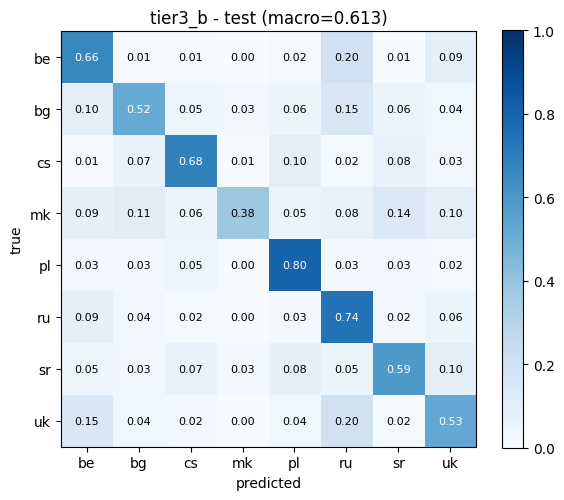

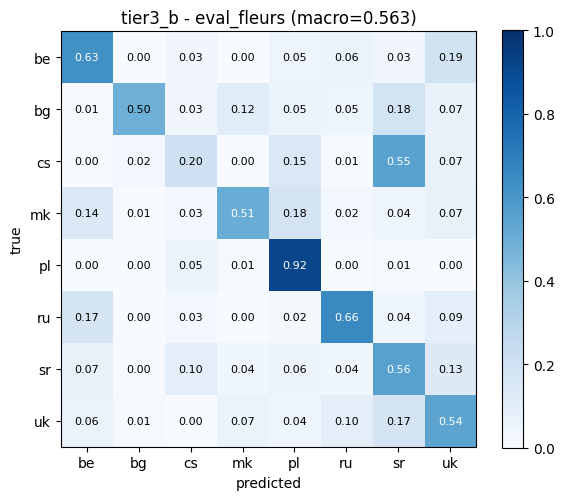


artifacts -> /kaggle/working/slavic_lid/results/tier3_b


In [8]:
## 7. Final eval + artifacts
import json, csv
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

ckpt = torch.load(f"{CKPT_DIR}/best.pt", map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model"]); model.eval()
print(f"loaded best: epoch {ckpt['epoch']}, macro={ckpt['macro']:.3f}")

def evaluate(loader, name):
    preds, trues = [], []
    with torch.no_grad():
        for wav, y in loader:
            wav = wav.to(DEVICE)
            with torch.amp.autocast('cuda'):
                preds.append(model(wav).argmax(1).cpu().numpy())
            trues.append(y.numpy())
    p = np.concatenate(preds); t = np.concatenate(trues)
    cm = confusion_matrix(t, p, labels=list(range(NUM_CLASSES)))
    pl = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
    micro = (p == t).mean(); macro = pl.mean()
    print(f"\n[{name}] micro={micro:.3f} macro={macro:.3f}")
    for lg, a in zip(LANGS, pl): print(f"  {lg}: {a:.3f}")
    return {"name": name, "micro": float(micro), "macro": float(macro),
            "per_lang": {lg: float(a) for lg, a in zip(LANGS, pl)},
            "cm": cm.tolist(), "pred": p.tolist(), "true": t.tolist()}

results = {n: evaluate(l, n) for n, l in
           [("test", test_loader), ("eval_fleurs", fleurs_loader)]}

with open(f"{RES_DIR}/metrics.json", "w") as f:
    json.dump({n: {k: v for k, v in r.items() if k not in ("pred", "true")}
               for n, r in results.items()}, f, indent=2)

with open(f"{RES_DIR}/test_predictions.csv", "w", newline="") as f:
    w = csv.writer(f); w.writerow(["true", "pred", "true_lang", "pred_lang"])
    for tt, pp in zip(results["test"]["true"], results["test"]["pred"]):
        w.writerow([tt, pp, LANGS[tt], LANGS[pp]])

for name, r in results.items():
    cm = np.array(r["cm"])
    cmn = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(LANGS)
    ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(LANGS)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(f"{RUN_NAME} - {name} (macro={r['macro']:.3f})")
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center",
                    color="white" if cmn[i,j] > 0.5 else "black", fontsize=8)
    plt.colorbar(im, ax=ax); plt.tight_layout()
    plt.savefig(f"{RES_DIR}/cm_{name}.png", dpi=150); plt.show()

print(f"\nartifacts -> {RES_DIR}")


t-SNE sample size: 1000
embeddings: (1000, 1024)


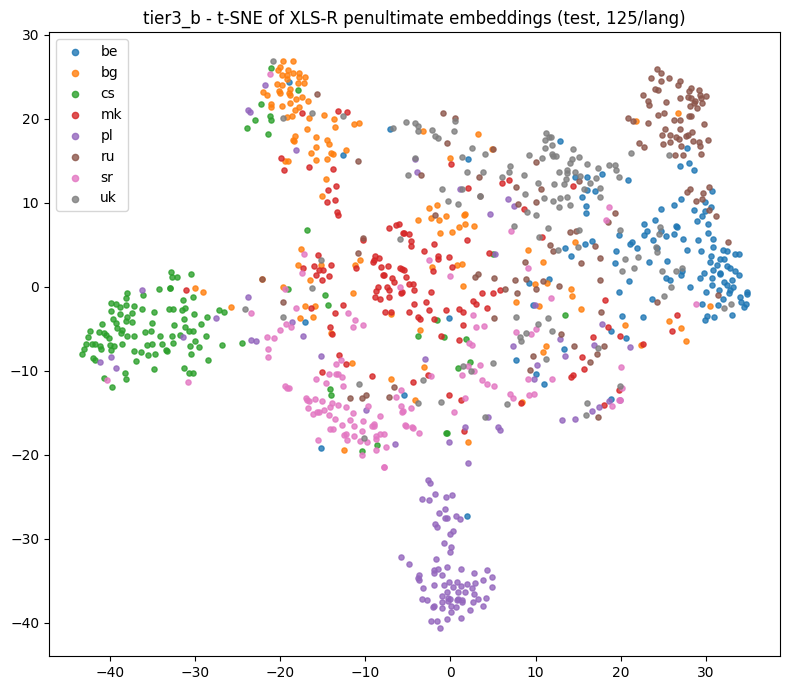

saved -> /kaggle/working/slavic_lid/results/tier3_b/tsne_test.png


In [9]:
## 8. t-SNE of penultimate-layer (1024-d) embeddings
from sklearn.manifold import TSNE

test_labels_full = np.load(f"{RAW_DIR}/test_labels.npy", mmap_mode="r")
rng = np.random.default_rng(SEED)
idxs = []
for c in range(NUM_CLASSES):
    cls_idx = np.where(test_labels_full[:] == c)[0]
    idxs.append(rng.choice(cls_idx, size=min(125, len(cls_idx)), replace=False))
sample_idx = np.concatenate(idxs)
print("t-SNE sample size:", len(sample_idx))

tsne_loader = DataLoader(Subset(WavDataset("test"), sample_idx.tolist()),
                         batch_size=16, shuffle=False, num_workers=4, pin_memory=True)

embs, labs = [], []
model.eval()
with torch.no_grad():
    for wav, y in tsne_loader:
        wav = wav.to(DEVICE)
        with torch.amp.autocast('cuda'):
            embs.append(model.features(wav).float().cpu().numpy())
        labs.append(y.numpy())
E = np.concatenate(embs); Y = np.concatenate(labs)
print("embeddings:", E.shape)

Z = TSNE(n_components=2, perplexity=30, init="pca", random_state=SEED).fit_transform(E)

fig, ax = plt.subplots(figsize=(8, 7))
cmap = plt.get_cmap("tab10")
for c in range(NUM_CLASSES):
    m = (Y == c)
    ax.scatter(Z[m, 0], Z[m, 1], s=14, alpha=0.8, color=cmap(c), label=LANGS[c])
ax.set_title(f"{RUN_NAME} - t-SNE of XLS-R penultimate embeddings (test, 125/lang)")
ax.legend(loc="best", markerscale=1.2)
plt.tight_layout()
plt.savefig(f"{RES_DIR}/tsne_test.png", dpi=150)
plt.show()
print(f"saved -> {RES_DIR}/tsne_test.png")
